In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df=pd.read_csv('../data/merged_data.csv')

print("shape: ",df.shape)
print("Data loaded sucessfully!")


shape:  (940, 22)
Data loaded sucessfully!


In [4]:
Cluster_data = df[['TotalSteps', 'Calories', 'VeryActiveMinutes', 'SedentaryMinutes']]

print("Cluster data shape: ",Cluster_data.shape)
Cluster_data.head()

Cluster data shape:  (940, 4)


,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes
0,13162,1985,25,728
1,10735,1797,21,776
2,10460,1776,30,1218
3,9762,1745,29,726
4,12669,1863,36,773


In [5]:
Scaler = StandardScaler()
scaled_data = Scaler.fit_transform(Cluster_data)

print("Scaled data shape: ",scaled_data.shape)
print("Data is ready for clustering!")

Scaled data shape:  (940, 4)
Data is ready for clustering!


In [6]:
Kmeans=KMeans(n_clusters=3,random_state=40)
Kmeans.fit(scaled_data)

df['Cluster'] = Kmeans.labels_

print("Clusterinf dine")
print(df['Cluster'].value_counts())


Clusterinf dine
Cluster
1    429
0    333
2    178
Name: count, dtype: int64


In [8]:
cluster_summary=df.groupby('Cluster')['TotalSteps'].mean()
print(cluster_summary)

Cluster
0     7906.198198
1     4738.904429
2    14122.932584
Name: TotalSteps, dtype: float64


In [15]:
Cluster_labels = {
    2:'Active',
    0:'Moderate',
    1:'Sedentary'
}
df['ClusterLabel'] = df['Cluster'].map(Cluster_labels)

print(df['ClusterLabel'].value_counts())


ClusterLabel
Sedentary    429
Moderate     333
Active       178
Name: count, dtype: int64


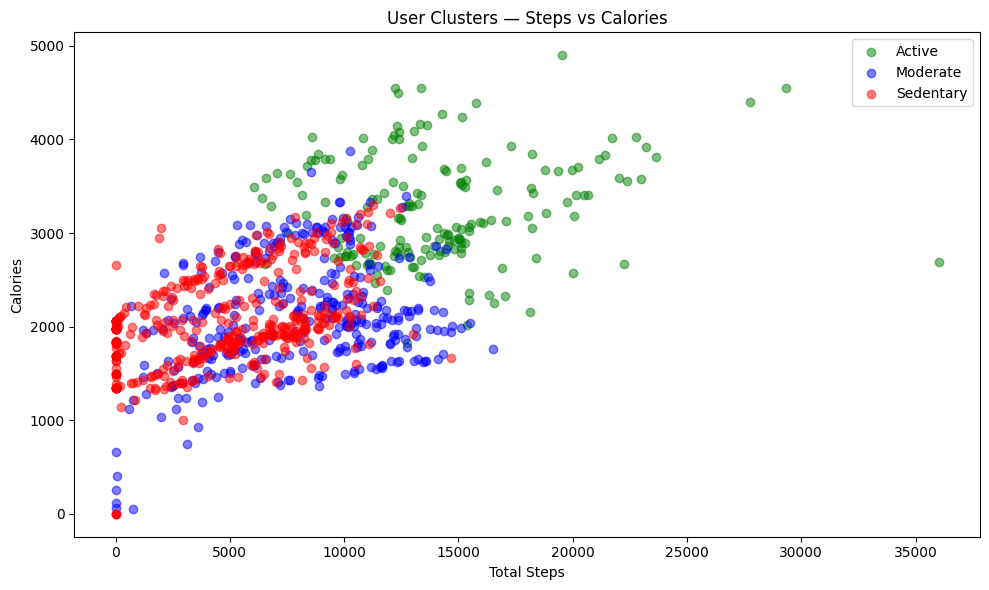

In [16]:
plt.figure(figsize=(10,6))
colors = {'Active':'green', 'Moderate':'blue', 'Sedentary':'red'}

for label in ['Active', 'Moderate', 'Sedentary']:
    cluster = df[df['ClusterLabel'] == label]
    plt.scatter(cluster['TotalSteps'], cluster['Calories'], 
                label=label, 
                color=colors[label], 
                alpha=0.5)

plt.title('User Clusters — Steps vs Calories')
plt.xlabel('Total Steps')
plt.ylabel('Calories')
plt.legend()
plt.tight_layout()
plt.show()